In [20]:
import numpy as np
import matplotlib.pyplot as plt

from neuromodes.eigen import EigenSolver
from neuromodes.io import fetch_surf
from neuromodes.mesh import estimate_fwhm, estimate_fwhm_fem

In [21]:
nGroups = 10
density = '32k'
hemi = 'l'

solver = EigenSolver(fetch_surf(surf_type='sphere', density=density, hemi=hemi)[0]).solve(n_modes=nGroups**2)
RADIUS = np.mean(np.linalg.norm(solver.geometry.v, axis=1)) # empirical radius of the sphere mesh
GROUPS = np.repeat(np.arange(1,nGroups), 2 * np.arange(1,nGroups) + 1)

### Visualisation of empirical vs. theoretical eigenvalue

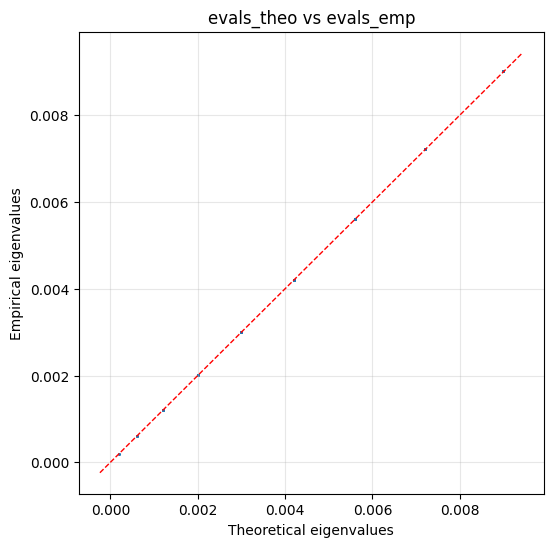

In [22]:
evals_theo = GROUPS * (GROUPS + 1) / RADIUS**2
evals_emp = solver.evals[1:]

fig = plt.figure(figsize=(6,6))

plt.scatter(evals_theo, evals_emp, s=1, alpha=0.8)
plt.plot(plt.xlim(), plt.xlim(), "r--", linewidth=1)

plt.xlabel("Theoretical eigenvalues")
plt.ylabel("Empirical eigenvalues")
plt.title("evals_theo vs evals_emp")
plt.grid(True, alpha=0.3)


### Visualisation of `estimate_fwhm` vs. theoretical wavelength

In [23]:
wavelength_theo = 2 * np.pi / np.sqrt(evals_theo)
wavelength_wb = np.pi / np.sqrt(2*np.log(2)) * estimate_fwhm(solver.geometry, solver.emodes[:,1:])
wavelength_fem = np.pi / np.sqrt(2*np.log(2)) * estimate_fwhm_fem(solver, solver.emodes[:,1:])

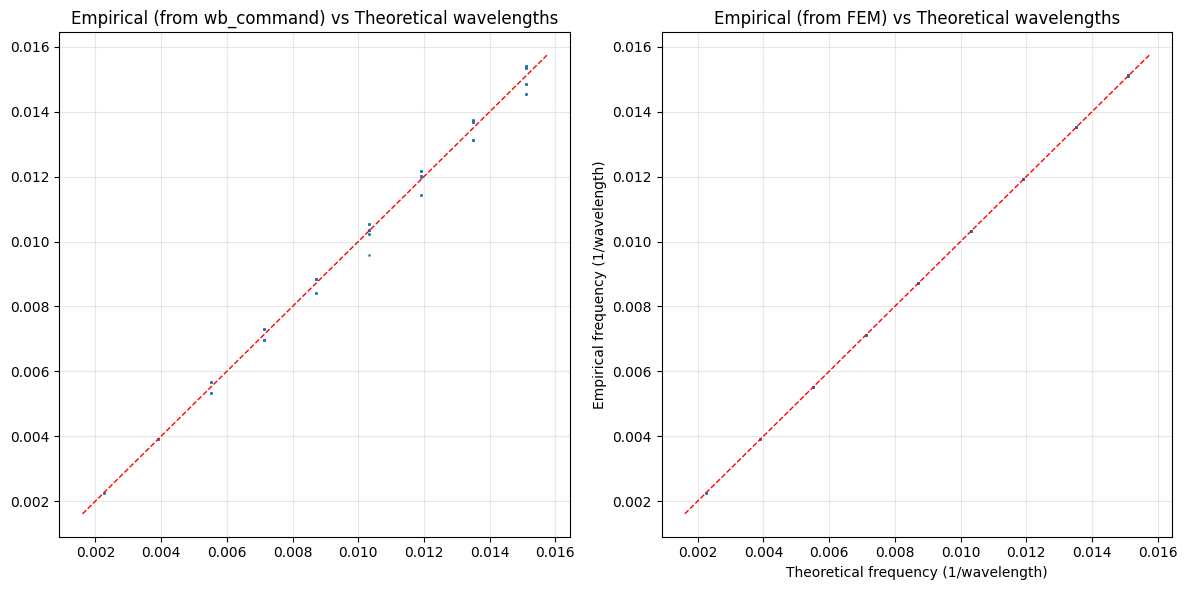

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].scatter(1/wavelength_theo,1/wavelength_wb, s=1, alpha=0.8)
axs[0].plot(axs[0].get_xlim(), axs[0].get_xlim(), "r--", linewidth=1)

axs[0].set_title("Empirical (from wb_command) vs Theoretical wavelengths")
axs[1].set_xlabel("Theoretical frequency (1/wavelength)")
axs[1].set_ylabel("Empirical frequency (1/wavelength)")
axs[0].grid(True, alpha=0.3)

axs[1].scatter(1/wavelength_theo,1/wavelength_fem, s=1, alpha=0.8)
axs[1].plot(axs[1].get_xlim(), axs[1].get_xlim(), "r--", linewidth=1)

axs[1].set_title("Empirical (from FEM) vs Theoretical wavelengths")
axs[1].set_xlabel("Theoretical frequency (1/wavelength)")
axs[1].set_ylabel("Empirical frequency (1/wavelength)")
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

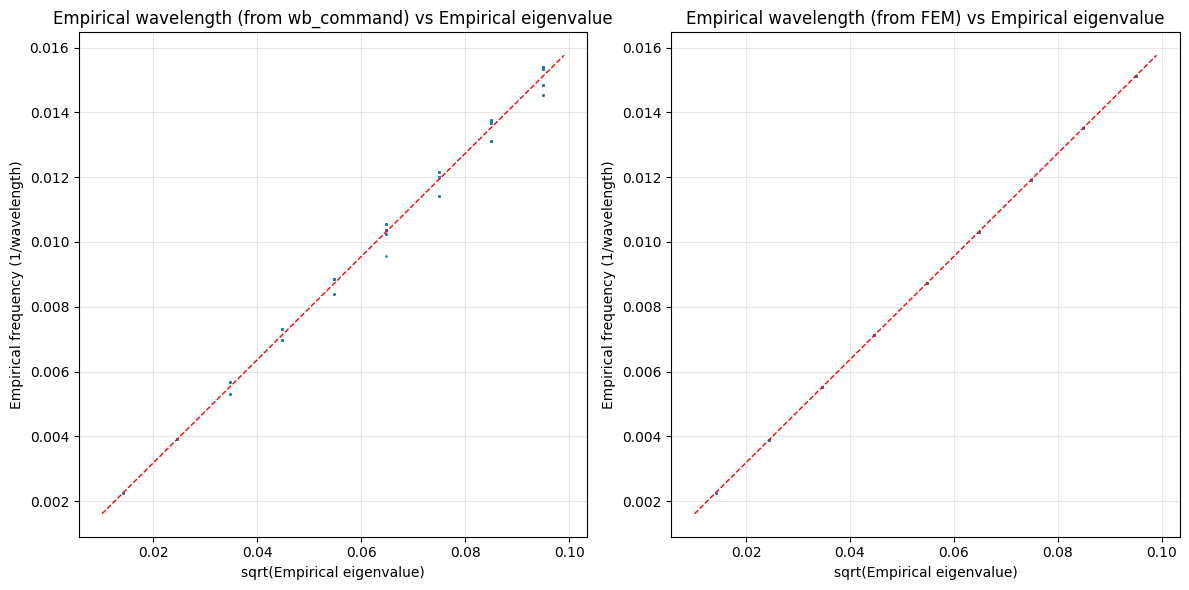

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].scatter(np.sqrt(evals_emp),1/wavelength_wb, s=1, alpha=0.8)
axs[0].plot(axs[0].get_xlim(), np.array(axs[0].get_xlim())/(2*np.pi), "r--", linewidth=1)

axs[0].set_title("Empirical wavelength (from wb_command) vs Empirical eigenvalue")
axs[0].set_xlabel("sqrt(Empirical eigenvalue)")
axs[0].set_ylabel("Empirical frequency (1/wavelength)")
axs[0].grid(True, alpha=0.3)

axs[1].scatter(np.sqrt(evals_emp),1/wavelength_fem, s=1, alpha=0.8)
axs[1].plot(axs[1].get_xlim(), np.array(axs[1].get_xlim())/(2*np.pi), "r--", linewidth=1)

axs[1].set_title("Empirical wavelength (from FEM) vs Empirical eigenvalue")
axs[1].set_xlabel("sqrt(Empirical eigenvalue)")
axs[1].set_ylabel("Empirical frequency (1/wavelength)")
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()